In [42]:
import qutip as qt
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from IPython.display import HTML
from tqdm.notebook import trange,tqdm
# import cProfile, pstats, io
# from pstats import SortKey
import sys
sys.path.append( '../src' )
from QFINumerics import QFI, genChannel, searchForState, calc_for_state, FI_observable

In [2]:
#qutip.settings.core.atol=1e-60
#utip.settings.core.rtol=1e-60

In [3]:
#state = searchForState()

In [4]:
#n = qt.tensor(qt.num(5),qt.identity(5),qt.identity(6))
#chan = genChannel()
#pth0 = qt.thermal_dm(5,(1-.1)*.1)
#rho = qt.vector_to_operator(chan*qt.operator_to_vector(state.proj()))
#rel_ent = qt.entropy_relative(pth0,rho.ptrace([0]),tol=1e-50)
#max_QFI = QFI(rho,n)
#print(rel_ent)
#print(max_QFI)

In [5]:
testfun = lambda eta,n_th,n_sq: (8*eta*n_sq*(n_sq + 1)*(4*eta*n_sq*(n_sq + 1) - (eta*n_sq + n_sq - n_th*(eta - 1) + 1)**2)/(4*eta*n_sq*(n_sq + 1) - (4*eta*n_sq*(n_sq + 1) - np.sqrt(-4*eta*n_sq*(n_sq + 1) + (eta*n_sq + n_sq + n_th*(1 - eta) + 1)**2)*(-eta*n_sq + n_sq + n_th*(eta - 1)) + (eta*n_sq + n_sq - n_th*(eta - 1) + 1)**2)*(4*eta*n_sq*(n_sq + 1) - np.sqrt(-4*eta*n_sq*(n_sq + 1) + (eta*n_sq + n_sq + n_th*(1 - eta) + 1)**2)*(eta*n_sq - n_sq + n_th*(1 - eta)) + (eta*n_sq + n_sq + n_th*(1 - eta) + 1)**2) - (eta*n_sq + n_sq - n_th*(eta - 1) + 1)**2))

In [6]:
alttest = lambda eta,n_th,n_sq: (4*eta*n_sq*(-n_sq - 1)/(2*eta*n_sq*n_th + eta*n_sq + eta*n_th - 2*n_sq*n_th - n_sq - n_th - 1))

In [7]:
test3 = lambda eta,n_th,n_sq:4*(eta**2*n_sq*(n_sq+1) + eta*(1-eta)*(n_th+1)*n_sq + eta*(1-eta)*n_th*(n_sq+1))

In [8]:
dim = 10
nth = .1
a = qt.destroy(dim)
ad = a.dag()
iden = qt.identity(dim)
pth = qt.thermal_dm(dim,nth)
n = qt.tensor(qt.num(dim),iden)
a1 = qt.tensor(a,iden)
theta = np.pi/2
zeroket = qt.basis(dim,0)
oneket = qt.basis(dim,1)
twoket = qt.basis(dim,2)

In [9]:
nth = .001
eta = .00005
nsq = 3
xsi = 2*np.arcsinh(np.sqrt(nsq))
S = qt.squeezing(qt.tensor(a,iden),qt.tensor(iden,a),xsi)
sq = S*qt.tensor(zeroket,zeroket)
nsqad = qt.expect(n,sq)
print(nsqad)
print(testfun(eta,nth,nsqad))
print(alttest(eta,nth,nsqad))
print(test3(eta,nth,nsqad))
print(calc_for_state(sq.proj(),n,a1,[dim,nth,eta]))

2.7181805883424377
0.0005421280025319443
0.0005427165321875355
0.0005449972105973212
[np.float64(6.142846104143472e-05), np.float64(0.0019544866366272323)]


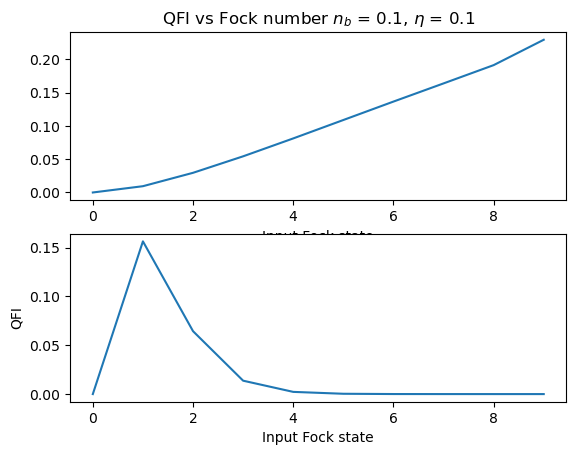

In [10]:
QFIs = np.zeros(dim)
REs = np.zeros(dim)
nth = .1
eta = .1
for i in range(dim):
    nket = qt.basis(dim,i)
    unnorm = qt.tensor(zeroket,nket) + qt.tensor(nket,zeroket)
    statet = unnorm.proj().unit()
    [REs[i],QFIs[i]] = calc_for_state(statet,n,a1,[dim,nth,eta])
fig,ax = plt.subplots(2)
ax[0].set_xlabel('Input Fock state')
ax[1].set_xlabel('Input Fock state')
ax[1].set_ylabel('Relative Entropy')
ax[1].set_ylabel('QFI')
ax[0].set_title(r'Relative Entropy vs Fock number $n_b$ = {nb}, $\eta$ = {eta}'.format(nb=nth,eta=eta))
ax[0].set_title(r'QFI vs Fock number $n_b$ = {nb}, $\eta$ = {eta}'.format(nb=nth,eta=eta))
ax[0].plot(REs)
ax[1].plot(QFIs)

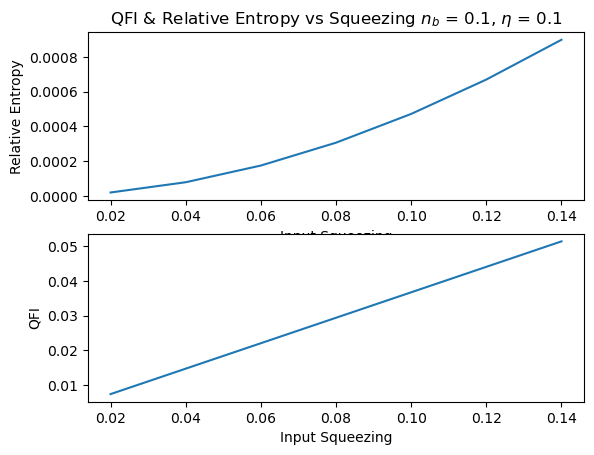

In [11]:
maxphotons = 7
QFIs = np.zeros(maxphotons)
REs = np.zeros(maxphotons)
nth = .1
eta = .1
nsq = .02
sqs = (np.arange(maxphotons)+1)*nsq
for i in range(maxphotons):
    xsi = 2*np.arcsinh(np.sqrt(sqs[i]))
    S = qt.squeezing(qt.tensor(a,iden),qt.tensor(iden,a),xsi)
    sq = S*qt.tensor(zeroket,zeroket)
    statet = sq.unit().proj()
    [REs[i],QFIs[i]] = calc_for_state(statet,n,a1,[dim,nth,eta])
fig,ax = plt.subplots(2)
ax[0].set_xlabel('Input Squeezing')
ax[1].set_xlabel('Input Squeezing')
ax[0].set_ylabel('Relative Entropy')
ax[1].set_ylabel('QFI')
ax[0].set_title(r'QFI & Relative Entropy vs Squeezing $n_b$ = {nb}, $\eta$ = {eta}'.format(nb=nth,eta=eta))
ax[0].plot(sqs,REs)
ax[1].plot(sqs,QFIs)

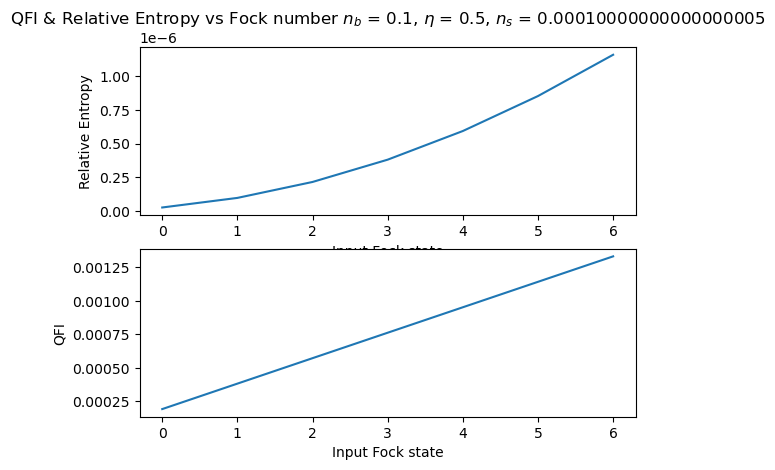

In [12]:
maxphotons = 7
QFIs = np.zeros(maxphotons)
REs = np.zeros(maxphotons)
nth = .1
eta = .5
xsi = 2*np.arcsinh(np.sqrt(.0001))
S = qt.squeezing(qt.tensor(a,iden),qt.tensor(iden,a),xsi)
sq = S*qt.tensor(zeroket,zeroket)
for i in range(maxphotons):
    unnorm = a1**i * sq
    statet = unnorm.unit().proj()
    [REs[i],QFIs[i]] = calc_for_state(statet,n,a1,[dim,nth,eta])
fig,ax = plt.subplots(2)
ax[0].set_xlabel('Input Fock state')
ax[1].set_xlabel('Input Fock state')
ax[0].set_ylabel('Relative Entropy')
ax[1].set_ylabel('QFI')
ax[0].set_title(r'QFI & Relative Entropy vs Fock number $n_b$ = {nb}, $\eta$ = {eta}, $n_s$ = {nsq}'.format(nb=nth,eta=eta,nsq = np.sinh(xsi/2)**2))
ax[0].plot(REs)
ax[1].plot(QFIs)

[0 0 0 0 0 0 0]


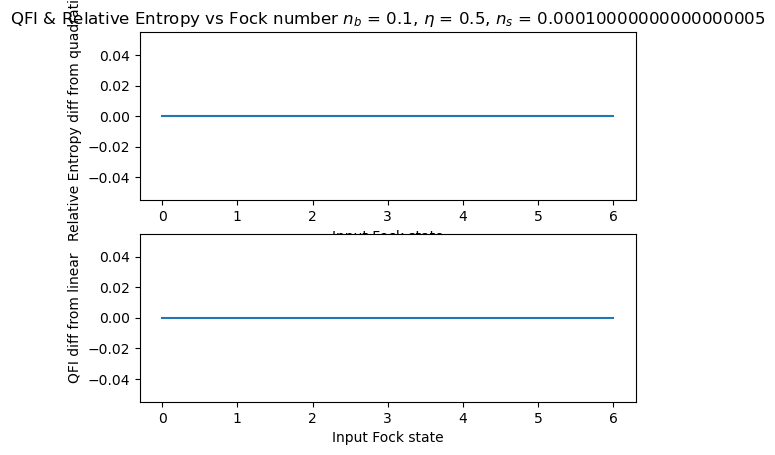

In [13]:
QFIDiff = np.arange(maxphotons)
REDiff = np.arange(maxphotons)
for i in range(maxphotons):
    REDiff[i] = REs[i]-(1+i)**2*REs[0]
    QFIDiff[i] = QFIs[i]-(1+i)*QFIs[0]
fig,ax = plt.subplots(2)
ax[0].set_xlabel('Input Fock state')
ax[1].set_xlabel('Input Fock state')
ax[0].set_ylabel('Relative Entropy diff from quadratic')
ax[1].set_ylabel('QFI diff from linear')
ax[0].set_title(r'QFI & Relative Entropy vs Fock number $n_b$ = {nb}, $\eta$ = {eta}, $n_s$ = {nsq}'.format(nb=nth,eta=eta,nsq = np.sinh(xsi/2)**2))
ax[0].plot(REDiff)
ax[1].plot(QFIDiff)
print(REDiff)

In [14]:
#states = []
#wdims = 6
#sdims = 5
#idims = 5
#probabilities = np.zeros(wdims)
#for i in range(wdims):
#    staten = qt.tensor(qt.identity(sdims),qt.identity(idims),qt.basis(wdims,i).dag())*state
#    probabilities[i] = staten.norm()**2
#    toadd = qt.dimensions.from_tensor_rep(np.reshape(qt.dimensions.to_tensor_rep(staten.unit()),[sdims,idims]),[[sdims],[idims]])
#    states.append(toadd)
#print(probabilities)
#[fig,ani] = qt.anim_matrix_histogram(states,bar_style='abs',color_style='phase',options={'bars_alpha':.8})
#HTML(ani.to_jshtml())

In [15]:
#states = []
#wdims = 6
#sdims = 5
#idims = 5
#probabilities = np.zeros(wdims)
#n = qt.tensor(qt.num(sdims),qt.identity(idims))
#chan = genChannel()
#rho = qt.vector_to_operator(chan*qt.operator_to_vector(state.proj()))
#QFIs = np.zeros(wdims)
#for i in range(wdims):
#    staten = (qt.tensor(qt.identity(sdims),qt.identity(idims),qt.basis(wdims,i).dag())*rho*qt.tensor(qt.identity(sdims),qt.identity(idims),qt.basis(wdims,i))).drop_scalar_dims(inplace=True)
#    probabilities[i] = staten.norm()
#    QFIs[i] = QFI(staten.unit(),n)
#print(probabilities)
#print(QFIs)
#print(np.sum(probabilities*QFIs))

In [16]:
#adverstate = state.ptrace([0])
#nbar = qt.expect(qt.num(sdims),adverstate)
#print(nbar)
#thermeq = qt.thermal_dm(sdims,nbar)
#qt.entropy_relative(thermeq,adverstate)

In [17]:
#qt.plot_wigner(adverstate,projection='3d')

In [18]:
#qt.plot_wigner(thermeq,projection='3d')

In [19]:
#qt.plot_wigner(qt.rand_ket(5))

In [20]:
# Code to generate mixed photon subtracted squeezed states
# that look thermal
def makeSubtractSqueezed(dim = 3, nbright = .01, nsq = .001):
    wdims = dim
    sdims = dim
    idims = dim
    nsamp = nbright/nsq - 1
    a = qt.destroy(sdims)
    iden = qt.identity(sdims)
    zeroket = qt.basis([sdims,idims])
    a1 = qt.tensor(a,iden)

    xsi = 2*np.arcsinh(np.sqrt(nsq))
    S = qt.squeezing(a1,qt.tensor(iden,a),xsi)
    sq = S*zeroket
    if nsamp > 0:
        # populates diagonal terms using truncated operator expression
        beta = np.log(1.0 / nsamp + 1.0)
        diags = [np.exp(-beta * i) for i in range(wdims)]
        diags = diags / np.sum(diags)
        #diags = [nsamp**i/(nsamp+1)**(i+1) for i in range(wdims)]
    else:
        return qt.tensor(sq,qt.basis(wdims))


    ket = 0
    for i in range(wdims):
        unnorm = a1**i * sq
        ket = ket + np.sqrt(diags[i])*qt.tensor(unnorm.unit(),qt.basis(wdims,i))
    return ket

In [21]:
# Code to generate mixed photon subtracted squeezed states
# that look thermal
def makeSubtractSqueezed2(dim=5, nbright = .01, nsamp = .001):
    a = qt.destroy(dim)
    iden = qt.identity(dim)
    a1 = qt.tensor(a,iden)
    nsq = nbright/(nsamp+1)

    xsi = 2*np.arcsinh(np.sqrt(nsq))
    S = qt.tensor(qt.squeezing(a1,qt.tensor(iden,a),xsi),iden)
    #sq = S*zeroket
    if nsamp > 0:
        # populates diagonal terms using truncated operator expression
        beta = np.log(1.0 / nsamp + 1.0)
        diags = [np.exp(-beta * i) for i in range(dim)]
        diags = np.sqrt(diags / np.sum(diags))
        # diags = [nsamp**i/(nsamp+1)**(i+1) for i in range(dim)]
        #diags = np.sqrt(diags / np.sum(diags))
    else:
        return qt.tensor(sq,qt.basis(dim))


    ket = np.sum([S*qt.tensor(qt.basis(dim),qt.basis(dim,i),qt.basis(dim,i)) for i in range(dim)]*diags)
    return ket

  0%|          | 0/30 [00:00<?, ?it/s]

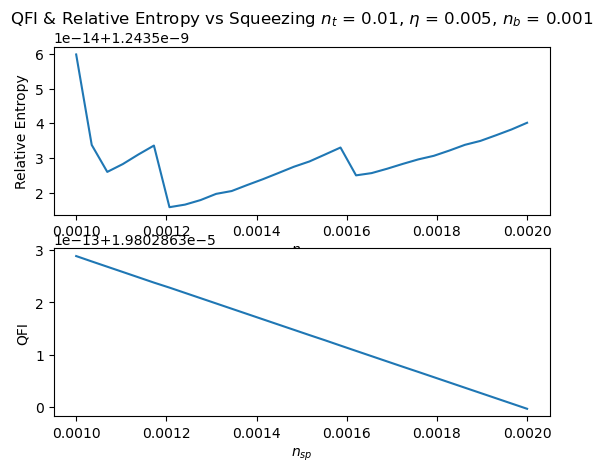

In [22]:
nbright = .001
eta = .005
nth = .01
samples = 30
wdims = 11
sdims = wdims
idims = sdims
chan = genChannel(dims=[sdims,sdims,idims,wdims], params=[eta,nth])
n = qt.tensor(qt.num(sdims),qt.identity(idims),qt.identity(wdims))
pth0 = qt.thermal_dm(sdims,(1-eta)*nth)



QFIs = np.zeros(samples)
REs = np.zeros(samples)
nsamps = np.linspace(.001,.002,samples)
for i in trange(samples):
    ket = makeSubtractSqueezed2(dim=idims,nbright=nbright,nsamp=nsamps[i])
    rho = qt.vector_to_operator(chan*qt.operator_to_vector(ket.proj()))
    QFIs[i] = QFI(rho,n)
    REs[i] = qt.entropy_relative(pth0,rho.ptrace([0]))
fig,ax = plt.subplots(2)
ax[0].set_xlabel(r'$n_{sp}$')
ax[1].set_xlabel(r'$n_{sp}$')
ax[0].set_ylabel('Relative Entropy')
ax[1].set_ylabel('QFI')
ax[0].set_title(r'QFI & Relative Entropy vs Squeezing $n_t$ = {nt}, $\eta$ = {eta}, $n_b$ = {nb}'.format(nt=nth,eta=eta,nb = nbright))
ax[0].plot(nsamps,REs)
ax[1].plot(nsamps,QFIs)

In [23]:
dim=7
ket = makeSubtractSqueezed2(dim=dim,nsamp=.03)
print(ket.norm())
adverstate = ket.proj().ptrace([0])
nbar = qt.expect(qt.num(dim),adverstate)
print(nbar)
thermeq = qt.thermal_dm(dim,nbar)
print(qt.entropy_relative(thermeq,adverstate,tol=1e-200))
a = qt.destroy(dim)
iden = qt.identity(dim)
zeroket = qt.basis([dim,dim])
a1 = qt.tensor(a,iden)
nsq =.01/(1.03)

xsi = 2*np.arcsinh(np.sqrt(nsq))
S = qt.squeezing(a1,qt.tensor(iden,a),xsi)

0.9999999999999999
0.009999999913863949
2.500777362968165e-14


In [24]:
tket = (qt.tensor(qt.identity(dim),qt.identity(dim),qt.fock(dim,3).dag())*ket).drop_scalar_dims(inplace=True).unit()
#print(tket)
targetket = (a1**3*S*zeroket).unit()
#print(targetket)
#print(S)
diff = tket - targetket
print(diff.norm())

1.9999999998866094


In [25]:
[_,_,probs] = qt.measurement.measurement_statistics(tket.proj(),qt.tensor(qt.position(dim),qt.position(dim)))

In [26]:
probs

[0.0010466033124227202,
 0.030487834769222708,
 0.010115084921279115,
 0.12795501511414678,
 0.10736110496835835,
 0.09690712184861022,
 0.4463616389659552,
 0.04428670238505237,
 0.08864094765570979,
 0.03524315157817576,
 0.009281377023269248,
 0.002297582077721838,
 1.5835380076575288e-05]

In [27]:
state0 = qt.tensor(qt.coherent(dim,.1),qt.coherent(dim,-.1)).proj()
thetas = np.linspace(.1,2*np.pi-.1,100)
idims = dim
sdims = dim
G = qt.tensor(qt.identity(idims),qt.num(sdims))
op = qt.tensor(qt.position(dim),qt.position(dim))
ath = qt.tensor(qt.destroy(dim),qt.identity(dim))
asi = qt.tensor(qt.identity(dim),qt.destroy(dim)) # can't call this as, because it's a keyword
GU = np.pi *1j*(ath.dag()*asi +asi.dag()*ath)/2
    # Define the beamsplitter transform
U = GU.expm()
#op = U*tensor(num(dim),num(dim))*U.dag()
[_,_,probs0] = qt.measurement.measurement_statistics(state0,op)
numprobs = len(probs0)
def for_jacobian_lin(theta):
    U = (1j*theta[0]*G).expm()
    state = U*state0*U.dag()
    [_,_,probs] = qt.measurement.measurement_statistics(state,op)
    logprob = np.log(probs)
    return logprob
def for_jacobian(thetas):
    print(np.shape(thetas))
    return np.apply_along_axis(for_jacobian_lin, axis=0, arr=thetas)
def getprobs(thetas):
    output = np.zeros((numprobs,len(thetas)))
    for i in range(len(thetas)):
        U = (1j*thetas[i]*G).expm()
        state = U*state0*U.dag()
        [_,_,probs] = qt.measurement.measurement_statistics(state,op)
        output[:,i] = probs
    return output
print(FI_observable(state0,G,op,[.01,2*np.pi-.01]))
#print(np.shape(for_jacobian(thetas)))
res = sp.differentiate.jacobian(for_jacobian,np.reshape(thetas,(1,100)))
dlogp = res.df[:,0,:]
probs = getprobs(thetas)
expects = np.sum(dlogp**2*probs,axis=0)
FI = np.max(expects)
thetamax = thetas[np.argmax(expects)]

[np.float64(0.0015388277710783728), np.float64(1.5916124513079764)]
(1, 1, 100)
(1, 1, 100, 8)
(1, 1, 100, 2)
(1, 1, 100, 2)


In [28]:
FI

np.float64(0.001539180305927641)

In [29]:
thetamax

np.float64(4.708473717560293)

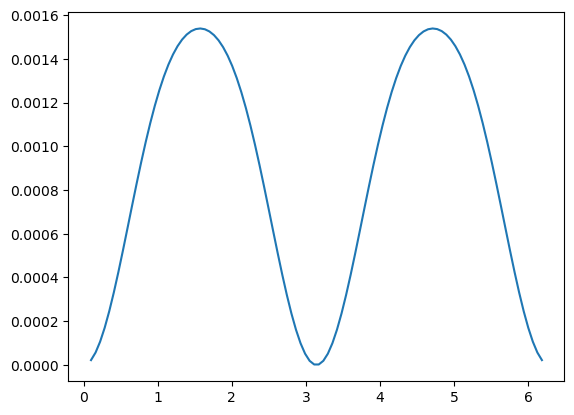

In [30]:
plt.plot(thetas,expects)

In [31]:
QFI(state0,G)

np.float64(0.040000000000000875)

In [32]:
np.shape(np.reshape(thetas,(1,1,100)))[1:]

(1, 100)

In [33]:
KO=qt.to_kraus(genChannel(dims=[3,3,3,3]))

In [34]:
def array_to_ket(x,dims):
    length = np.prod(dims)
    xc = x[0:length] +1j*x[length:]
    return qt.dimensions.from_tensor_rep(np.reshape(xc,np.append(dims,[1])),[dims,[1]])

def ket_to_array(ket):
    xc =  np.ndarray.flatten(qt.dimensions.to_tensor_rep(ket))
    return np.append(np.real(xc),np.imag(xc))

In [57]:
sdim = 5
idim = 5
adim = 5
tdim = 5
dims = [sdim,idim,adim]
eta = .1
nth = .1
n = qt.tensor(qt.num(sdim),qt.identity([idim,adim]))
max_rel = .01
T = .05
startingpoint = qt.tensor(qt.basis(sdim),qt.rand_ket([idim,adim]))
chan = genChannel(dims=[tdim,sdim,idim,adim],params = [eta,nth])
pth0 = qt.thermal_dm(sdim,(1-eta)*nth)
iters = 20
def constraint_f(x):
    ket = array_to_ket(x,dims)
    return qt.entropy_relative(pth0,ket.unit().proj().ptrace([0]),tol=1e-50)
nlc = sp.optimize.NonlinearConstraint(constraint_f,-np.inf,max_rel)
minimizer_kwargs = {'constraints': nlc}
def to_optimize(x):
    ket = array_to_ket(x,dims)
    rho = qt.vector_to_operator(chan*qt.operator_to_vector(ket.unit().proj()))
    return -QFI(rho,n)
class MyTakeStep:
   def __init__(self, dims, stepsize=0.01):
       self.stepsize = stepsize
       self.dims =  dims
       self.rng = np.random.default_rng()
   def __call__(self, x):
       s = self.stepsize
       rket = qt.rand_ket(dims,seed=self.rng)
       ket = array_to_ket(x,dims).unit()
       return ket_to_array(ket+rket)
class TqdmUpTo(tqdm):
    """Provides `update_to(n)` which uses `tqdm.update(delta_n)`."""
    def update_to(self, x,f,accept):
        self.update()  # also sets self.n = b * bsize
take_step = MyTakeStep(dims)
x0 = ket_to_array(startingpoint)
with TqdmUpTo(total=iters+1) as t:
    res = sp.optimize.basinhopping(to_optimize,x0,take_step=take_step,minimizer_kwargs=minimizer_kwargs,T=T,stepsize=.01,niter=iters,callback=t.update_to)
res

  0%|          | 0/21 [00:00<?, ?it/s]

/home/dominic/.conda/envs/research/lib/python3.13/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


                    message: ['requested number of basinhopping iterations completed successfully']
                    success: True
                        fun: -0.05427364788538317
                          x: [ 1.978e-02 -4.109e-02 ...  2.248e-02
                               1.213e-02]
                        nit: 20
      minimization_failures: 1
                       nfev: 145430
                       njev: 579
 lowest_optimization_result:     message: Optimization terminated successfully
                                 success: True
                                  status: 0
                                     fun: -0.05427364788538317
                                       x: [ 1.978e-02 -4.109e-02 ...
                                            2.248e-02  1.213e-02]
                                     nit: 27
                                     jac: [ 6.569e-04 -1.358e-03 ...
                                           -1.941e-02 -1.065e-02]
                           

In [53]:
state = array_to_ket(res.x,dims).unit()

In [54]:
state

Quantum object: dims=[[5, 5, 5], [1]], shape=(125, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.36398617-7.48789238e-02j]
 [-0.14302375-1.62075896e-01j]
 [-0.10498684+7.43564786e-02j]
 [ 0.09990763-8.31665718e-02j]
 [-0.15254912+7.78193987e-02j]
 [ 0.00658723+2.58761711e-01j]
 [-0.12067911+4.43524195e-02j]
 [-0.14309724+2.34447972e-01j]
 [ 0.34210431+6.08151447e-02j]
 [-0.05677863+7.27254105e-02j]
 [-0.06339415-7.05901901e-02j]
 [ 0.01362883+4.52174208e-02j]
 [-0.09383302-1.57713899e-01j]
 [-0.01019348+1.67161323e-02j]
 [ 0.10609857-2.08756346e-02j]
 [ 0.03362618+1.06901205e-01j]
 [-0.13448653+1.38297984e-01j]
 [-0.31905364-1.11758522e-02j]
 [ 0.18540761+2.75596990e-02j]
 [-0.11463904-1.27202755e-01j]
 [-0.06142207+5.75479247e-02j]
 [-0.03150871-3.18759877e-02j]
 [ 0.05063474-2.74339015e-02j]
 [-0.19035373-1.03611526e-01j]
 [ 0.03536595-1.20444785e-01j]
 [ 0.00328449-1.35162576e-02j]
 [ 0.05680664-2.50670304e-02j]
 [ 0.00494547-1.22290943e-01j]
 [ 0.04550256+1.04687527e-02j]
 [-0.04928

In [55]:
startingpoint

Quantum object: dims=[[5, 5, 5], [1]], shape=(125, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.39007377-0.08286301j]
 [-0.15304573-0.16850428j]
 [-0.09877872+0.07909918j]
 [ 0.11019   -0.093347j  ]
 [-0.15664401+0.0804486j ]
 [ 0.00663119+0.26846955j]
 [-0.11496067+0.0418961j ]
 [-0.15486932+0.25962301j]
 [ 0.37316716+0.06030645j]
 [-0.05439881+0.06879885j]
 [-0.07403613-0.08076995j]
 [ 0.01458722+0.04863707j]
 [-0.10597709-0.17330727j]
 [-0.00316935+0.02275151j]
 [ 0.0989353 -0.02571858j]
 [ 0.02524428+0.1074709j ]
 [-0.13390203+0.13135269j]
 [-0.3537964 -0.01877134j]
 [ 0.20284393+0.02988782j]
 [-0.10552747-0.11243729j]
 [-0.06603043+0.07574949j]
 [-0.02643733-0.02248607j]
 [ 0.06413558-0.02935276j]
 [-0.19727232-0.12377796j]
 [ 0.04398042-0.11928738j]
 [ 0.        +0.j        ]
 [ 0.        -0.j        ]
 [-0.        +0.j        ]
 [ 0.        +0.j        ]
 [-0.        +0.j        ]
 [ 0.        +0.j        ]
 [-0.        +0.j        ]
 [-0.        +0.j        ]
 [ 0.        +0.j 